In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast
import numpy as np

In [2]:
# 1. FUNCIONES DE PROCESAMIENTO DE DATOS
# ==========================================================

def calcular_matrices_transicion(rutas):
    """Calcula las matrices de cantidades y probabilidades a partir de una serie de rutas."""
    transiciones = Counter()
    niveles_unicos = set()

    for ruta in rutas.dropna():
        nodos = [n.strip() for n in str(ruta).split('->')]
        niveles_unicos.update(nodos)
        
        for i in range(len(nodos)-1):
            transiciones[(nodos[i], nodos[i+1])] += 1

    niveles = sorted(list(niveles_unicos))
    
    # Matriz de Cantidades
    df_cantidades = pd.DataFrame(0, index=niveles, columns=niveles)
    for (origen, destino), cantidad in transiciones.items():
        df_cantidades.at[origen, destino] = cantidad

    # Matriz de Probabilidades
    df_probabilidades = df_cantidades.div(df_cantidades.sum(axis=1), axis=0).fillna(0)
    
    return df_cantidades, df_probabilidades, transiciones

def extraer_origen_destino_final(valor):
    """Extrae el primer y último nivel de una ruta representada como string de lista."""
    if isinstance(valor, str) and valor.startswith('['):
        try:
            lista = ast.literal_eval(valor)
        except:
            return None
    elif isinstance(valor, list):
        lista = valor
    else:
        return None
    
    if len(lista) > 0:
        return f"{lista[0]} ➔ {lista[-1]}"
    return None

def asignar_periodo(fecha, periodos):
    """Asigna un período de tiempo según la fecha dada."""
    if pd.isna(fecha):
        return 'Sin Dato/Otro'
    
    fecha_str = str(fecha)[:10] 
    for nombre, inicio, fin in periodos:
        if inicio <= fecha_str <= fin:
            return nombre
    return 'Fuera de rango'

In [3]:
# 2. FUNCIONES DE VISUALIZACIÓN
# ==========================================================

def graficar_heatmaps(df_probabilidades, df_cantidades):
    """Grafica los dos heatmaps de transición."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor('white')

    # Gráfico 1: Probabilidades
    sns.heatmap(df_probabilidades, annot=True, fmt=".2f", cmap="Blues", 
                linewidths=0.5, linecolor='lightgray', vmin=0, vmax=1, ax=axes[0],
                cbar_kws={'label': 'Probabilidad de Transición'})
    axes[0].set_title("Matriz de Transición (Probabilidades)", fontsize=16, fontweight='bold', pad=15)
    axes[0].set_ylabel("Nivel de Origen", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Nivel de Destino", fontsize=12, fontweight='bold')

    # Gráfico 2: Cantidades
    sns.heatmap(df_cantidades, annot=True, fmt="d", cmap="Oranges", 
                linewidths=0.5, linecolor='lightgray', ax=axes[1],
                cbar_kws={'label': 'Cantidad de Traslados'})
    axes[1].set_title("Matriz de Frecuencia (Cantidades Absolutas)", fontsize=16, fontweight='bold', pad=15)
    axes[1].set_ylabel("Nivel de Origen", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Nivel de Destino", fontsize=12, fontweight='bold')

    for ax in axes:
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')
        plt.setp(ax.get_xticklabels(), rotation=45, ha='left', fontweight='bold')
        plt.setp(ax.get_yticklabels(), fontweight='bold')

    plt.tight_layout()
    plt.show()

def graficar_top_10(df, x_col, y_col, titulo, xlabel, ylabel, sufijo="pac.", palette="viridis", subtitulo=None):
    """Función genérica para evitar repetir el código de los gráficos de barras horizontales."""
    fig, ax = plt.subplots(figsize=(12, 7))
    fig.patch.set_facecolor('white')

    sns.barplot(data=df, x=x_col, y=y_col, palette=palette, ax=ax)

    margen = df[x_col].max() * 0.015 
    for index, row in df.iterrows():
        texto_etiqueta = f"{int(row[x_col])} {sufijo} ({row['Porcentaje']:.1f}%)"
        ax.text(row[x_col] + margen, index, texto_etiqueta, 
                color='#333333', va="center", fontweight='bold', fontsize=11)

    ax.set_title(titulo, fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')

    if subtitulo:
        plt.figtext(0.49, 0.87, subtitulo, ha="center", fontsize=11, color='dimgray')
        plt.tight_layout(rect=[0, 0, 1, 0.95])
    else:
        plt.tight_layout()

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params(axis='y', labelsize=12)

    plt.show()

def graficar_grilla_periodos(pivot_periodos, orden_columnas):
    """Grafica la evolución de saltos en una grilla 2x2."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.patch.set_facecolor('white')
    axes = axes.flatten()

    colores_periodos = sns.color_palette("Spectral", n_colors=len(orden_columnas))
    max_x = pivot_periodos.max().max() * 1.15

    for idx, periodo in enumerate(orden_columnas):
        ax = axes[idx]
        valores = pivot_periodos[periodo]
        y_pos = np.arange(len(valores))
        
        ax.barh(y_pos, valores, color=colores_periodos[idx], height=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(valores.index, fontweight='bold', fontsize=11)
        ax.set_xlim(0, max_x)
        
        ax.set_title(f"{periodo}", fontsize=15, fontweight='bold', pad=10)
        ax.set_xlabel("Traslados", fontsize=11, color='dimgray')
        
        for i, v in enumerate(valores):
            if v > 0:
                ax.text(v + (max_x * 0.015), i, str(int(v)), va='center', fontweight='bold', color='#333333', fontsize=10)

        sns.despine(ax=ax)

    plt.suptitle("Evolución del Top 10 Global de Traslados por Ola", fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

def graficar_grilla_trayectorias_periodos(pivot_periodos, orden_columnas):
    """Grafica la evolución de trayectorias completas en una grilla 2x2."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.patch.set_facecolor('white')
    axes = axes.flatten()

    colores_periodos = sns.color_palette("Spectral", n_colors=len(orden_columnas))
    max_x = pivot_periodos.max().max() * 1.15

    for idx, periodo in enumerate(orden_columnas):
        ax = axes[idx]
        valores = pivot_periodos[periodo]
        y_pos = np.arange(len(valores))
        
        ax.barh(y_pos, valores, color=colores_periodos[idx], height=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(valores.index, fontweight='bold', fontsize=11)
        ax.set_xlim(0, max_x)
        
        ax.set_title(f"{periodo}", fontsize=15, fontweight='bold', pad=10)
        ax.set_xlabel("Pacientes", fontsize=11, color='dimgray')
        
        for i, v in enumerate(valores):
            if v > 0:
                ax.text(v + (max_x * 0.015), i, str(int(v)), va='center', fontweight='bold', color='#333333', fontsize=10)

        sns.despine(ax=ax)

    plt.suptitle("Evolución del Top 10 de Trayectorias Completas por Ola", fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

def graficar_grilla_trayectorias_dinamico(df_cantidades, df_rankings, orden_columnas, n_top=8):
    """Grafica la evolución de trayectorias marcando el ranking específico de cada período."""
    # Aumentamos un poco el alto (14) porque ahora tendremos más de 10 barras (la unión de los tops)
    fig, axes = plt.subplots(2, 2, figsize=(18, 14)) 
    fig.patch.set_facecolor('white')
    axes = axes.flatten()

    colores_periodos = sns.color_palette("Spectral", n_colors=len(orden_columnas))
    max_x = df_cantidades.max().max() * 1.2 # Damos más margen para que entre el texto del ranking

    for idx, periodo in enumerate(orden_columnas):
        ax = axes[idx]
        valores = df_cantidades[periodo]
        rankings = df_rankings[periodo]
        
        y_pos = np.arange(len(valores))
        
        # LÓGICA DE COLOR: Color del período si está en el Top 8 de este período. Gris claro si no lo está.
        colores_barras = [
            colores_periodos[idx] if not pd.isna(rankings[ruta]) else '#e0e0e0'
            for ruta in valores.index
        ]
        
        ax.barh(y_pos, valores, color=colores_barras, height=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(valores.index, fontweight='bold', fontsize=10)
        ax.set_xlim(0, max_x)
        
        ax.set_title(f"{periodo}", fontsize=15, fontweight='bold', pad=10)
        ax.set_xlabel("Pacientes", fontsize=11, color='dimgray')
        
        for i, (ruta, v) in enumerate(valores.items()):
            if v > 0:
                rank = rankings[ruta]
                if not pd.isna(rank):
                    # Texto para los que SON del Top de este período
                    texto = f"[#{int(rank)}]  {int(v)} pac."
                    font_weight = 'bold'
                    color_texto = '#c21807' if rank <= 3 else '#333333' # Rojo oscuro para el podio (Top 1-3)
                else:
                    # Texto para los que NO son del Top de este período
                    texto = f"{int(v)}"
                    font_weight = 'normal'
                    color_texto = 'gray'
                    
                ax.text(v + (max_x * 0.015), i, texto, va='center', fontweight=font_weight, color=color_texto, fontsize=10)

        sns.despine(ax=ax)

    plt.suptitle(f"Evolución Dinámica: Unión de las Top {n_top} Trayectorias por Ola", fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


def graficar_top_10_apilado(df_pivot, titulo, xlabel, ylabel, total_general, sufijo="pac."):
    """Grafica barras horizontales apiladas según el motivo de egreso."""
    fig, ax = plt.subplots(figsize=(12, 7))
    fig.patch.set_facecolor('white')

    # Asegurarnos de que las columnas respeten los colores de nuestro diccionario
    colores_barras = [COLORES_MOTIVOS.get(col, '#333333') for col in df_pivot.columns]

    # Crear el gráfico de barras apilado
    df_pivot.plot(kind='barh', stacked=True, color=colores_barras, ax=ax, width=0.7)

    # Calcular los totales por barra para poner la etiqueta final
    totales = df_pivot.sum(axis=1)
    margen = totales.max() * 0.015 
    
    for i, (idx, total) in enumerate(totales.items()):
        if total > 0:
            porcentaje = (total / total_general) * 100
            texto_etiqueta = f"{int(total)} {sufijo} ({porcentaje:.1f}%)"
            ax.text(total + margen, i, texto_etiqueta, 
                    color='#333333', va="center", fontweight='bold', fontsize=11)

    ax.set_title(titulo, fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params(axis='y', labelsize=12)

    # Configurar leyenda afuera del gráfico
    plt.legend(title='Motivo Fin de Caso', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    plt.tight_layout()
    
    plt.show()

In [4]:
# 3. INICIO DE GRAFICOS
# ==========================================================

# if __name__ == "__main__":
    
############################################################
# CONFIGURACIÓN Y CARGA DE DATOS
############################################################
RUTA_EXCEL = "C:/Users/micag/Documents/RedesHospitales/data/revision_dfs.xlsx"
PERIODOS_COVID = [
    ('Primera Ola', '2020-06-01', '2020-10-31'),
    ('Intermedia', '2020-11-01', '2021-02-28'),
    ('Segunda Ola', '2021-03-01', '2021-07-31'),
    ('Post-vacunación', '2021-08-01', '2022-12-31')
]

trayectorias = pd.read_excel(RUTA_EXCEL, sheet_name=2)
df_pacientes = pd.read_excel(RUTA_EXCEL, sheet_name=0) 

# --- NUEVO: AGRUPAR TRAYECTORIAS LARGAS PARA LOS TOPS ---
def agrupar_trayectorias_largas(ruta):
    if pd.isna(ruta):
        return ruta
    # Contamos cuántos nodos (hospitales) tiene separando por la flecha
    nodos = str(ruta).split('->')
    if len(nodos) >= 4:
        return 'Más de 3 hospitales (4+)'
    return str(ruta).strip()

# Creamos una columna nueva para no romper los gráficos de saltos individuales
trayectorias['ruta_para_top'] = trayectorias['ruta_complejidad_str'].apply(agrupar_trayectorias_largas)
# --------------------------------------------------------

# DICCIONARIO DE COLORES PARA MOTIVOS
# ==========================================================
COLORES_MOTIVOS = {
    'alta': '#2ca02c',             # Verde
    'muerte': '#d62728',           # Rojo
    'hospital externo': '#ff7f0e', # Naranja
    'alta hotel': '#1f77b4',       # Azul
    'otro/desconocido': '#7f7f7f'  # Gris
}


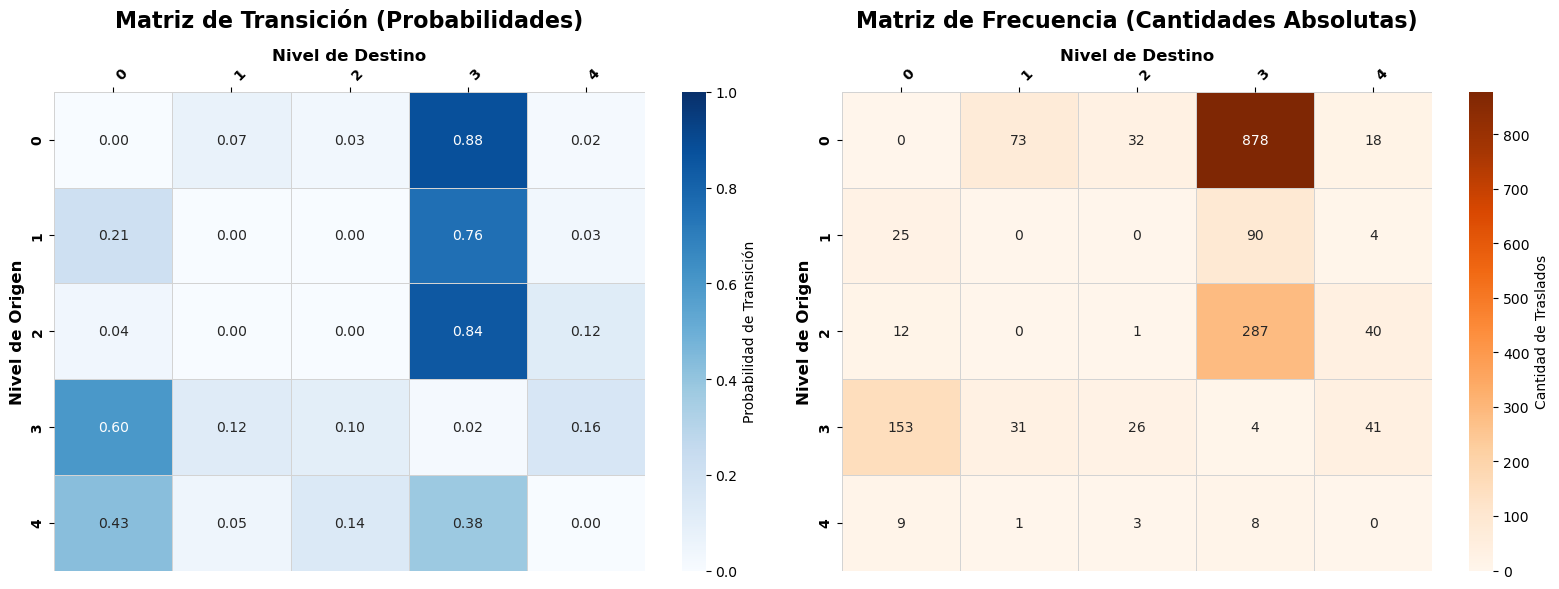

In [5]:
# GRÁFICO 1: MATRICES Y HEATMAPS
############################################################
# Este usa la original para no romper la contabilidad de tramo a tramo
df_cantidades, df_probabilidades, transiciones = calcular_matrices_transicion(trayectorias['ruta_complejidad_str'])
graficar_heatmaps(df_probabilidades, df_cantidades)


📌 RESUMEN DE COBERTURA DEL TOP 10 (TRAYECTORIAS)
Total de pacientes con traslados válidos: 1593
Pacientes DENTRO del Top 10: 1427 (89.6%)
Pacientes FUERA del Top 10:  166 (10.4%)



C:\Users\micag\AppData\Local\Temp\ipykernel_26044\3332738347.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x_col, y=y_col, palette=palette, ax=ax)


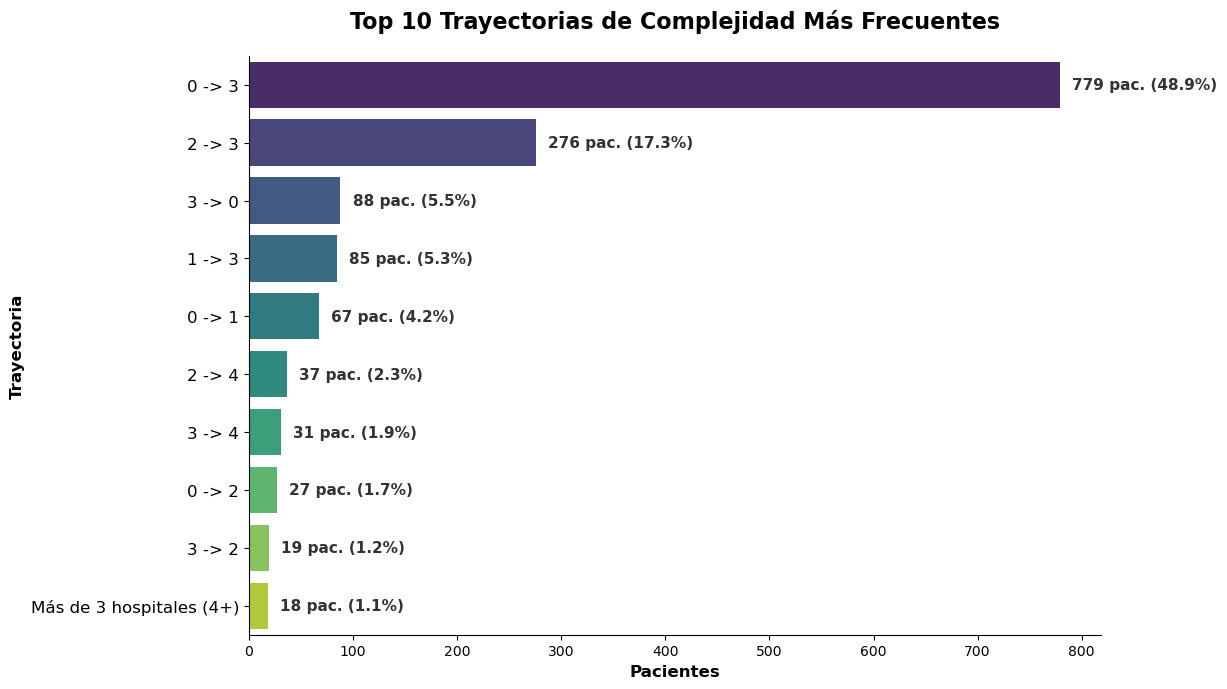

In [6]:
# GRÁFICO 2: TOP 10 TRAYECTORIAS COMPLETAS (MODIFICADO)
############################################################
# AHORA USA LA COLUMNA AGRUPADA ('ruta_para_top')
top_10 = trayectorias['ruta_para_top'].value_counts().head(10).reset_index()
top_10.columns = ['Ruta', 'Frecuencia']

# Calculamos totales para el porcentaje
total_validos = len(trayectorias.dropna(subset=['ruta_para_top']))
top_10['Porcentaje'] = (top_10['Frecuencia'] / total_validos) * 100

# --- NUEVO: CALCULAR QUÉ QUEDA AFUERA DEL TOP 10 ---
pacientes_en_top10 = top_10['Frecuencia'].sum()
pacientes_fuera = total_validos - pacientes_en_top10
porcentaje_fuera = (pacientes_fuera / total_validos) * 100

print("\n" + "="*50)
print("📌 RESUMEN DE COBERTURA DEL TOP 10 (TRAYECTORIAS)")
print("="*50)
print(f"Total de pacientes con traslados válidos: {total_validos}")
print(f"Pacientes DENTRO del Top 10: {pacientes_en_top10} ({(100 - porcentaje_fuera):.1f}%)")
print(f"Pacientes FUERA del Top 10:  {pacientes_fuera} ({porcentaje_fuera:.1f}%)")
print("="*50 + "\n")
# ---------------------------------------------------

graficar_top_10(
    df=top_10, x_col='Frecuencia', y_col='Ruta',
    titulo="Top 10 Trayectorias de Complejidad Más Frecuentes",
    xlabel="Pacientes", ylabel="Trayectoria", sufijo="pac."
)


RESUMEN DE COBERTURA DEL TOP 10 (GLOBAL: CON Y SIN TRASLADOS)
Total de pacientes en el sistema: 27823
Pacientes DENTRO del Top 10: 27464 (98.7%)
Pacientes FUERA del Top 10:  359 (1.3%)



C:\Users\micag\AppData\Local\Temp\ipykernel_26044\3332738347.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x_col, y=y_col, palette=palette, ax=ax)


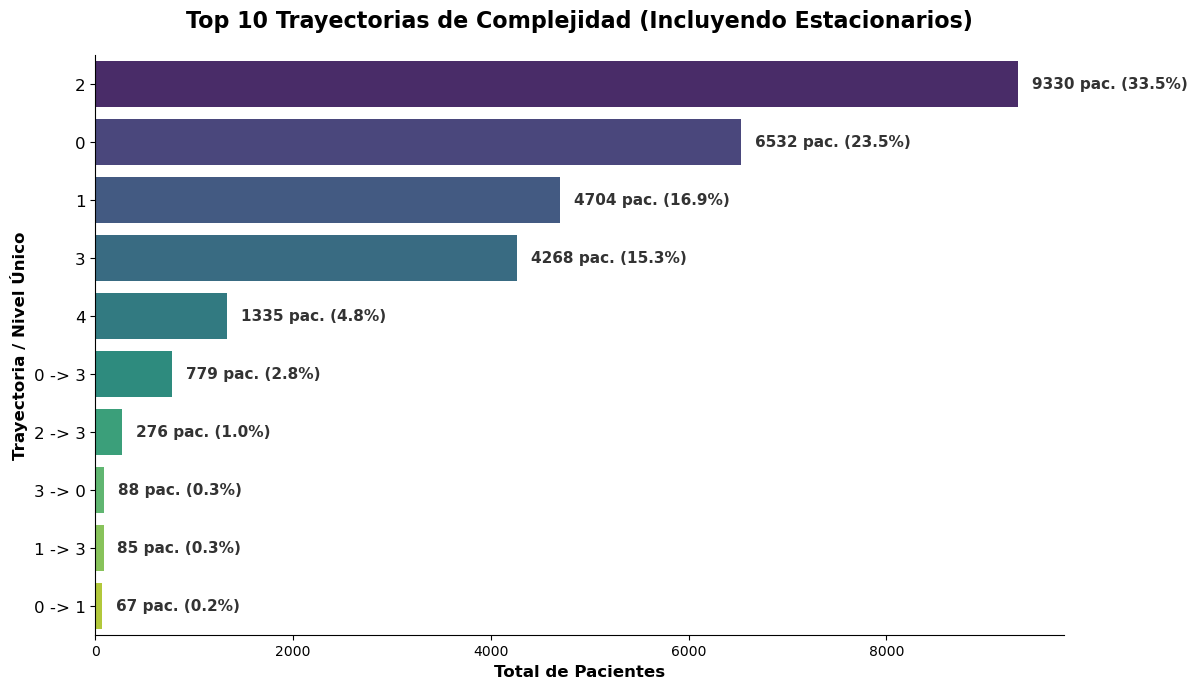

In [7]:
# new

# GRÁFICO 2: TOP 10 TRAYECTORIAS COMPLETAS (INCLUYENDO SIN TRASLADOS)
############################################################

# 1. Nombres de las columnas clave (Reemplazar si son distintos)
columna_id = 'paciente_id'
columna_hospital = 'hospital_origen' # Columna en df_pacientes con el nombre del hospital

# 2. Cargar el archivo de hospitales y complejidades
# Asegurate de poner la ruta correcta a tu archivo CSV
df_hospitales = pd.read_csv('C:/Users/micag/Documents/RedesHospitales/data/hospitales_coordenadas.csv', encoding='utf-8') 
# Nota: Si te da error de lectura, podés probar con encoding='latin1'

# 3. Separar a los pacientes: con traslado y sin traslado
pacientes_con_traslado = trayectorias[columna_id].dropna().unique()
df_sin_traslados = df_pacientes[~df_pacientes[columna_id].isin(pacientes_con_traslado)].copy()

# 4. Cruzar (Merge) df_sin_traslados con df_hospitales para traer la 'complejidad'
# Esto busca el nombre del hospital en df_sin_traslados y le pega la complejidad que figura en el CSV
df_sin_traslados = df_sin_traslados.merge(
    df_hospitales[['Nombre Hospital', 'complejidad']], # Solo traemos las columnas que nos importan
    left_on=columna_hospital, 
    right_on='Nombre Hospital', 
    how='left'
)

# 5. Asignar la "ruta" de un solo paso (ej: "Alta", "Media", etc.)
# Llenamos con "Desconocida" por si algún hospital de df_pacientes no estaba escrito igual en el CSV
df_sin_traslados['ruta_complejidad_str'] = df_sin_traslados['complejidad'].fillna('Desconocida').astype(str)
df_sin_traslados['ruta_complejidad_str'] = df_sin_traslados['ruta_complejidad_str'].str.replace('.0', '', regex=False)


# 6. Unir ambos universos en un solo DataFrame
todas_las_trayectorias = pd.concat([
    trayectorias[[columna_id, 'ruta_complejidad_str']],
    df_sin_traslados[[columna_id, 'ruta_complejidad_str']]
], ignore_index=True)

# 7. AHORA USA LA COLUMNA AGRUPADA ('ruta_para_top') SOBRE EL TOTAL
todas_las_trayectorias['ruta_para_top'] = todas_las_trayectorias['ruta_complejidad_str'].apply(agrupar_trayectorias_largas)

top_10 = todas_las_trayectorias['ruta_para_top'].value_counts().head(10).reset_index()
top_10.columns = ['Ruta', 'Frecuencia']

# Calculamos totales para el porcentaje sobre el universo TOTAL (con y sin traslados)
total_validos_global = len(todas_las_trayectorias.dropna(subset=['ruta_para_top']))
top_10['Porcentaje'] = (top_10['Frecuencia'] / total_validos_global) * 100

# --- RESUMEN DE COBERTURA ---
pacientes_en_top10 = top_10['Frecuencia'].sum()
pacientes_fuera = total_validos_global - pacientes_en_top10
porcentaje_fuera = (pacientes_fuera / total_validos_global) * 100

print("\n" + "="*50)
print("RESUMEN DE COBERTURA DEL TOP 10 (GLOBAL: CON Y SIN TRASLADOS)")
print("="*50)
print(f"Total de pacientes en el sistema: {total_validos_global}")
print(f"Pacientes DENTRO del Top 10: {pacientes_en_top10} ({(100 - porcentaje_fuera):.1f}%)")
print(f"Pacientes FUERA del Top 10:  {pacientes_fuera} ({porcentaje_fuera:.1f}%)")
print("="*50 + "\n")
# ---------------------------------------------------

graficar_top_10(
    df=top_10, x_col='Frecuencia', y_col='Ruta',
    titulo="Top 10 Trayectorias de Complejidad (Incluyendo Estacionarios)",
    xlabel="Total de Pacientes", ylabel="Trayectoria / Nivel Único", sufijo="pac."
)

C:\Users\micag\AppData\Local\Temp\ipykernel_26044\3332738347.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x_col, y=y_col, palette=palette, ax=ax)


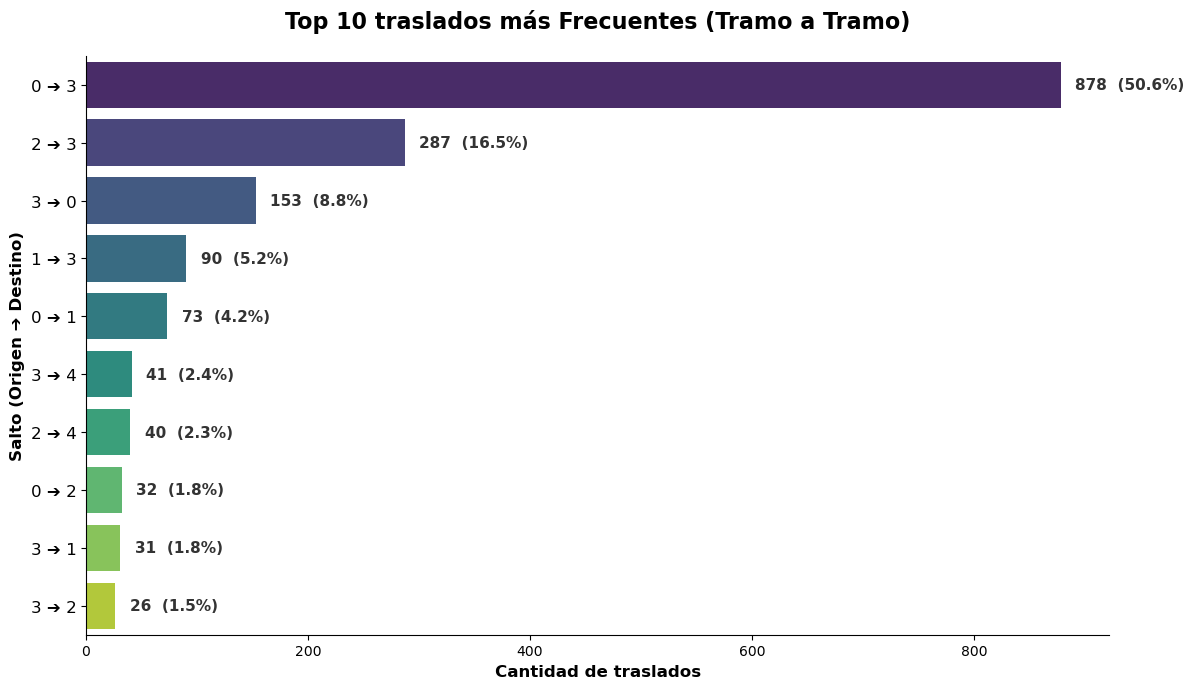

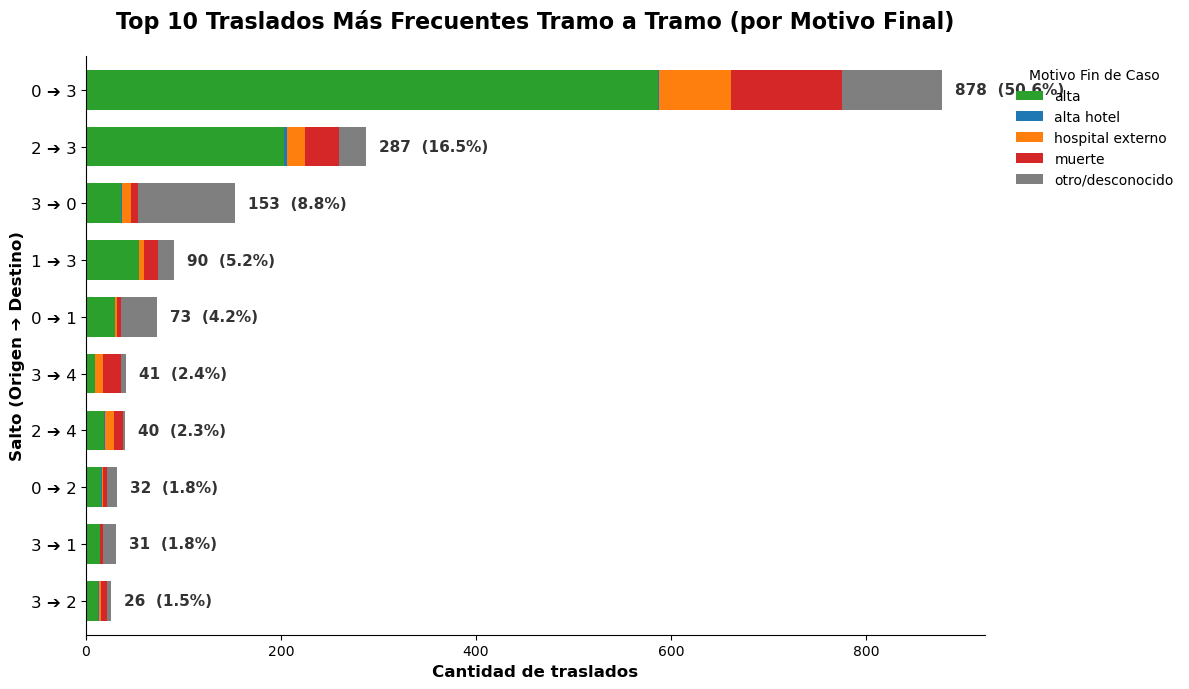

In [8]:
# GRÁFICO 3: TOP 10 SALTOS INDIVIDUALES
############################################################
df_saltos = pd.DataFrame(transiciones.items(), columns=['Salto_Tupla', 'Frecuencia'])
df_saltos['Salto'] = df_saltos['Salto_Tupla'].apply(lambda x: f"{x[0]} ➔ {x[1]}")
top_10_saltos = df_saltos.sort_values(by='Frecuencia', ascending=False).head(10).reset_index(drop=True)
top_10_saltos['Porcentaje'] = (top_10_saltos['Frecuencia'] / df_saltos['Frecuencia'].sum()) * 100

graficar_top_10(
    df=top_10_saltos, x_col='Frecuencia', y_col='Salto',
    titulo="Top 10 traslados más Frecuentes (Tramo a Tramo)",
    xlabel="Cantidad de traslados", ylabel="Salto (Origen ➔ Destino)", sufijo=""
)


# PREPARACIÓN MOTIVOS (Asegúrate de que trayectorias tenga la columna 'motivo_fin_caso')
trayectorias['motivo_fin_caso'] = trayectorias['motivo_fin_caso'].fillna('otro/desconocido')
trayectorias['motivo_fin_caso'] = trayectorias['motivo_fin_caso'].str.lower().str.strip() 



# GRÁFICO 3: TOP 10 SALTOS INDIVIDUALES APILADOS
############################################################
saltos_con_motivo = []
for _, row in trayectorias.dropna(subset=['ruta_complejidad_str']).iterrows():
    ruta = str(row['ruta_complejidad_str'])
    motivo = row['motivo_fin_caso']
    nodos = [n.strip() for n in ruta.split('->')]
    
    for i in range(len(nodos)-1):
        salto = f"{nodos[i]} ➔ {nodos[i+1]}"
        saltos_con_motivo.append({'Salto': salto, 'motivo_fin_caso': motivo})

df_saltos = pd.DataFrame(saltos_con_motivo)
total_saltos = len(df_saltos)
top_10_saltos_idx = df_saltos['Salto'].value_counts().head(10).index

df_saltos_top10 = df_saltos[df_saltos['Salto'].isin(top_10_saltos_idx)]
pivot_saltos = df_saltos_top10.groupby(['Salto', 'motivo_fin_caso']).size().unstack(fill_value=0)
pivot_saltos = pivot_saltos.reindex(top_10_saltos_idx[::-1])

graficar_top_10_apilado(
    df_pivot=pivot_saltos,
    titulo="Top 10 Traslados Más Frecuentes Tramo a Tramo (por Motivo Final)",
    xlabel="Cantidad de traslados", 
    ylabel="Salto (Origen ➔ Destino)", 
    total_general=total_saltos,
    sufijo=""
)

C:\Users\micag\AppData\Local\Temp\ipykernel_26044\3332738347.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x_col, y=y_col, palette=palette, ax=ax)


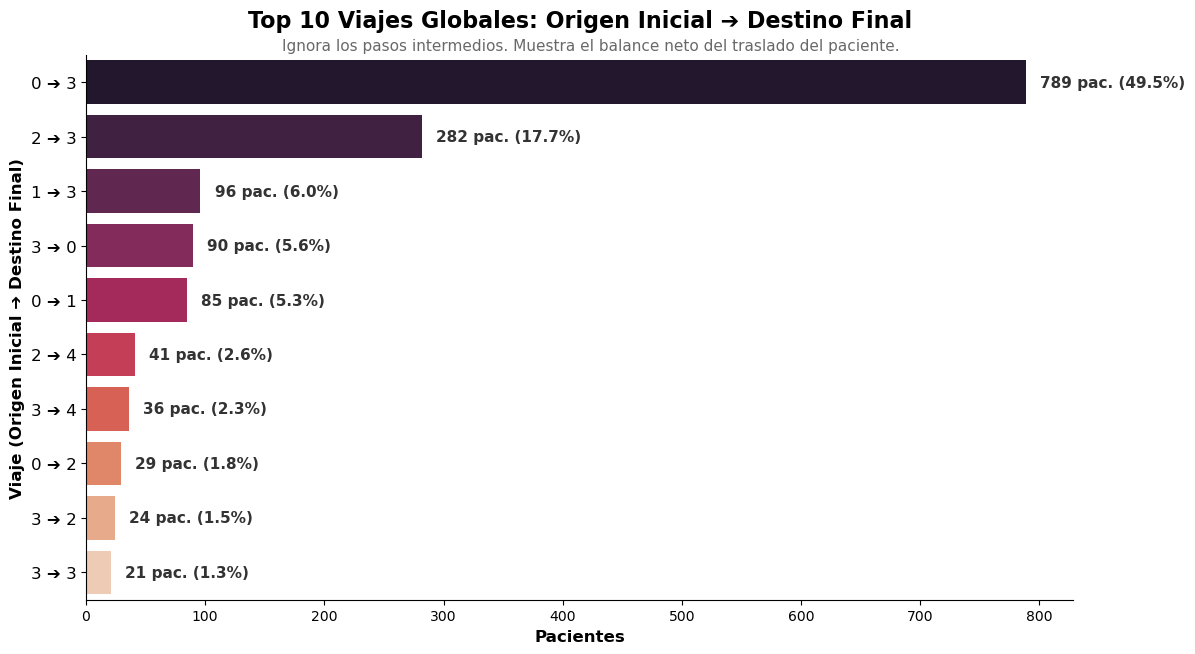

In [9]:
# GRÁFICO 4: VIAJE GLOBAL (ORIGEN ➔ DESTINO)
############################################################
trayectorias['viaje_global'] = trayectorias['ruta_complejidad_array'].apply(extraer_origen_destino_final)
df_viajes = trayectorias.dropna(subset=['viaje_global'])
top_10_viajes = df_viajes['viaje_global'].value_counts().head(10).reset_index()
top_10_viajes.columns = ['Viaje_Global', 'Frecuencia']
top_10_viajes['Porcentaje'] = (top_10_viajes['Frecuencia'] / len(df_viajes)) * 100

graficar_top_10(
    df=top_10_viajes, x_col='Frecuencia', y_col='Viaje_Global',
    titulo="Top 10 Viajes Globales: Origen Inicial ➔ Destino Final",
    xlabel="Pacientes", ylabel="Viaje (Origen Inicial ➔ Destino Final)", sufijo="pac.",
    palette="rocket",
    subtitulo="Ignora los pasos intermedios. Muestra el balance neto del traslado del paciente."
)

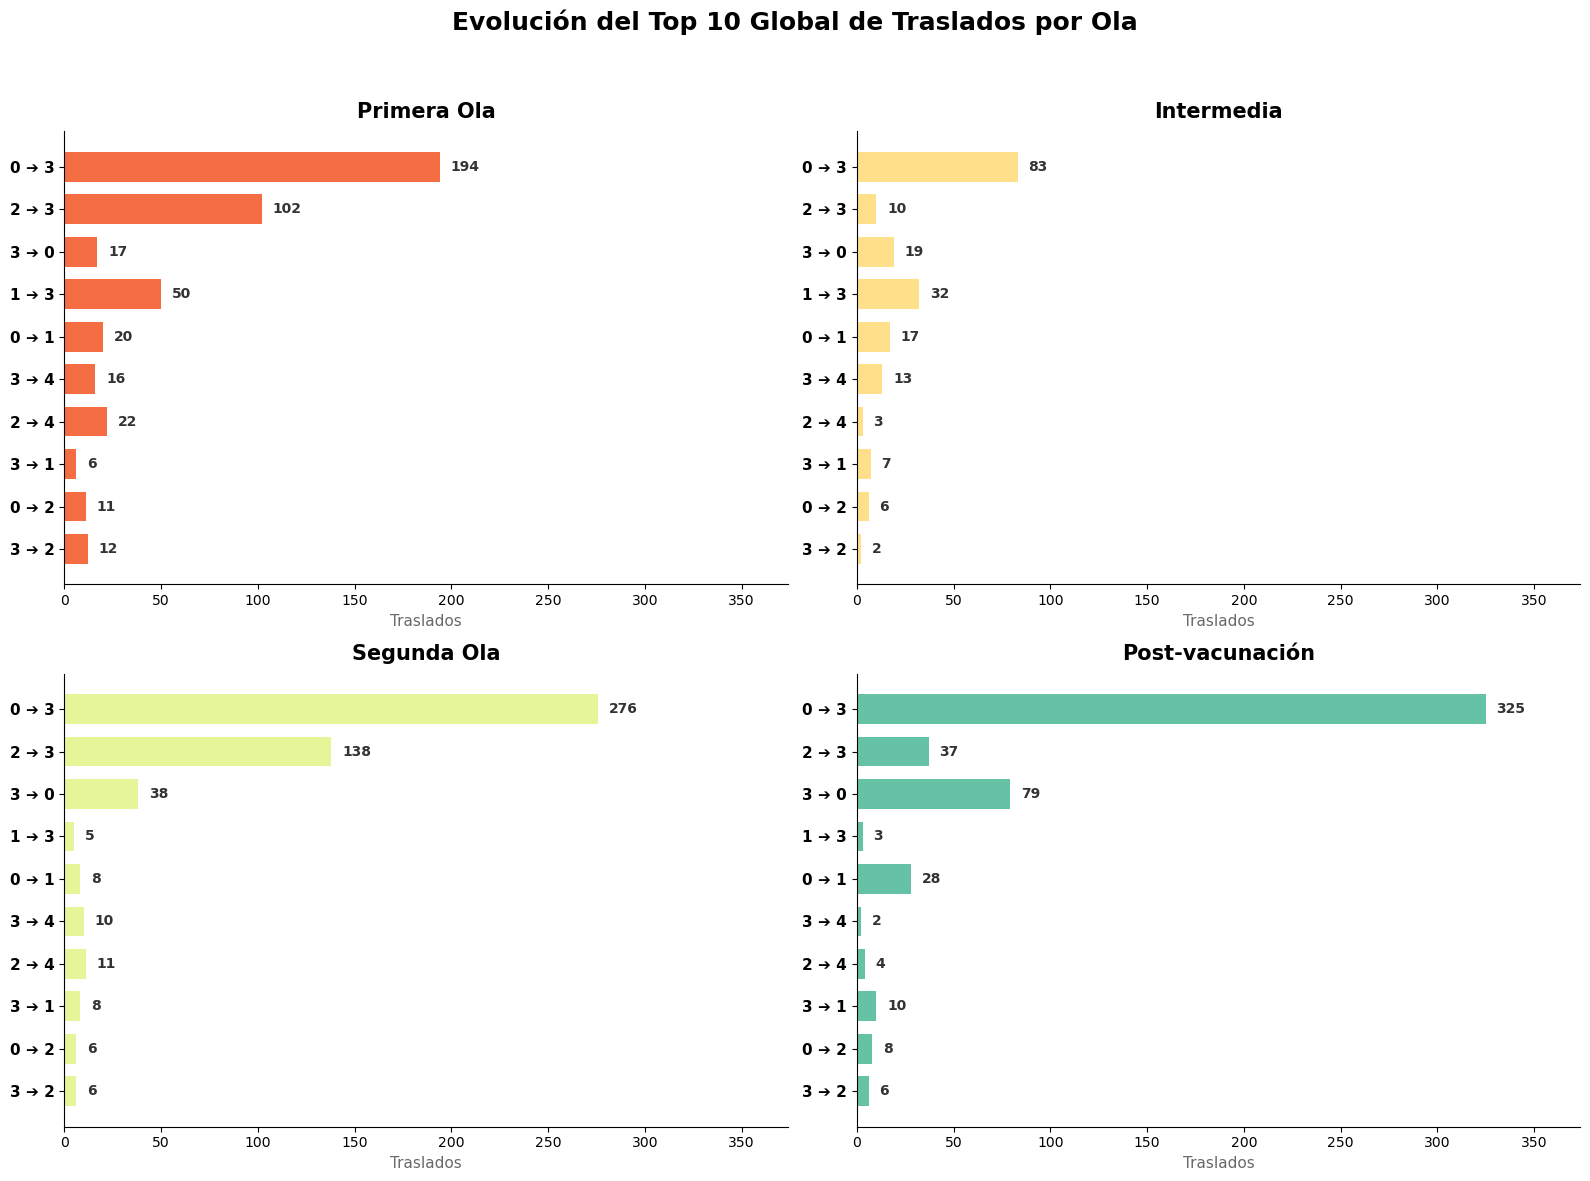

In [10]:
# GRÁFICO 5: ANÁLISIS TEMPORAL (GRILLA POR OLAS COVID)
############################################################
trayectorias['Periodo_Covid'] = trayectorias['fecha_ingreso_trayectoria'].apply(lambda x: asignar_periodo(x, PERIODOS_COVID))

saltos_temporales = []
for _, row in trayectorias.dropna(subset=['ruta_complejidad_str']).iterrows():
    ruta = [n.strip() for n in str(row['ruta_complejidad_str']).split('->')]
    if len(ruta) > 1:
        for i in range(len(ruta) - 1):
            saltos_temporales.append({
                'Salto': f"{ruta[i]} ➔ {ruta[i+1]}",
                'Periodo': row['Periodo_Covid']
            })

df_saltos_temp = pd.DataFrame(saltos_temporales)
nombres_periodos = [p[0] for p in PERIODOS_COVID]
df_saltos_temp = df_saltos_temp[df_saltos_temp['Periodo'].isin(nombres_periodos)]

top_10_nombres = df_saltos_temp['Salto'].value_counts().head(10).index
df_top10_temp = df_saltos_temp[df_saltos_temp['Salto'].isin(top_10_nombres)]

pivot_periodos = pd.crosstab(df_top10_temp['Salto'], df_top10_temp['Periodo'])
pivot_periodos['Total'] = pivot_periodos.sum(axis=1)
pivot_periodos = pivot_periodos.sort_values('Total', ascending=True).drop(columns=['Total'])

orden_columnas_existentes = [p for p in nombres_periodos if p in pivot_periodos.columns]
pivot_periodos = pivot_periodos[orden_columnas_existentes]

graficar_grilla_periodos(pivot_periodos, orden_columnas_existentes)

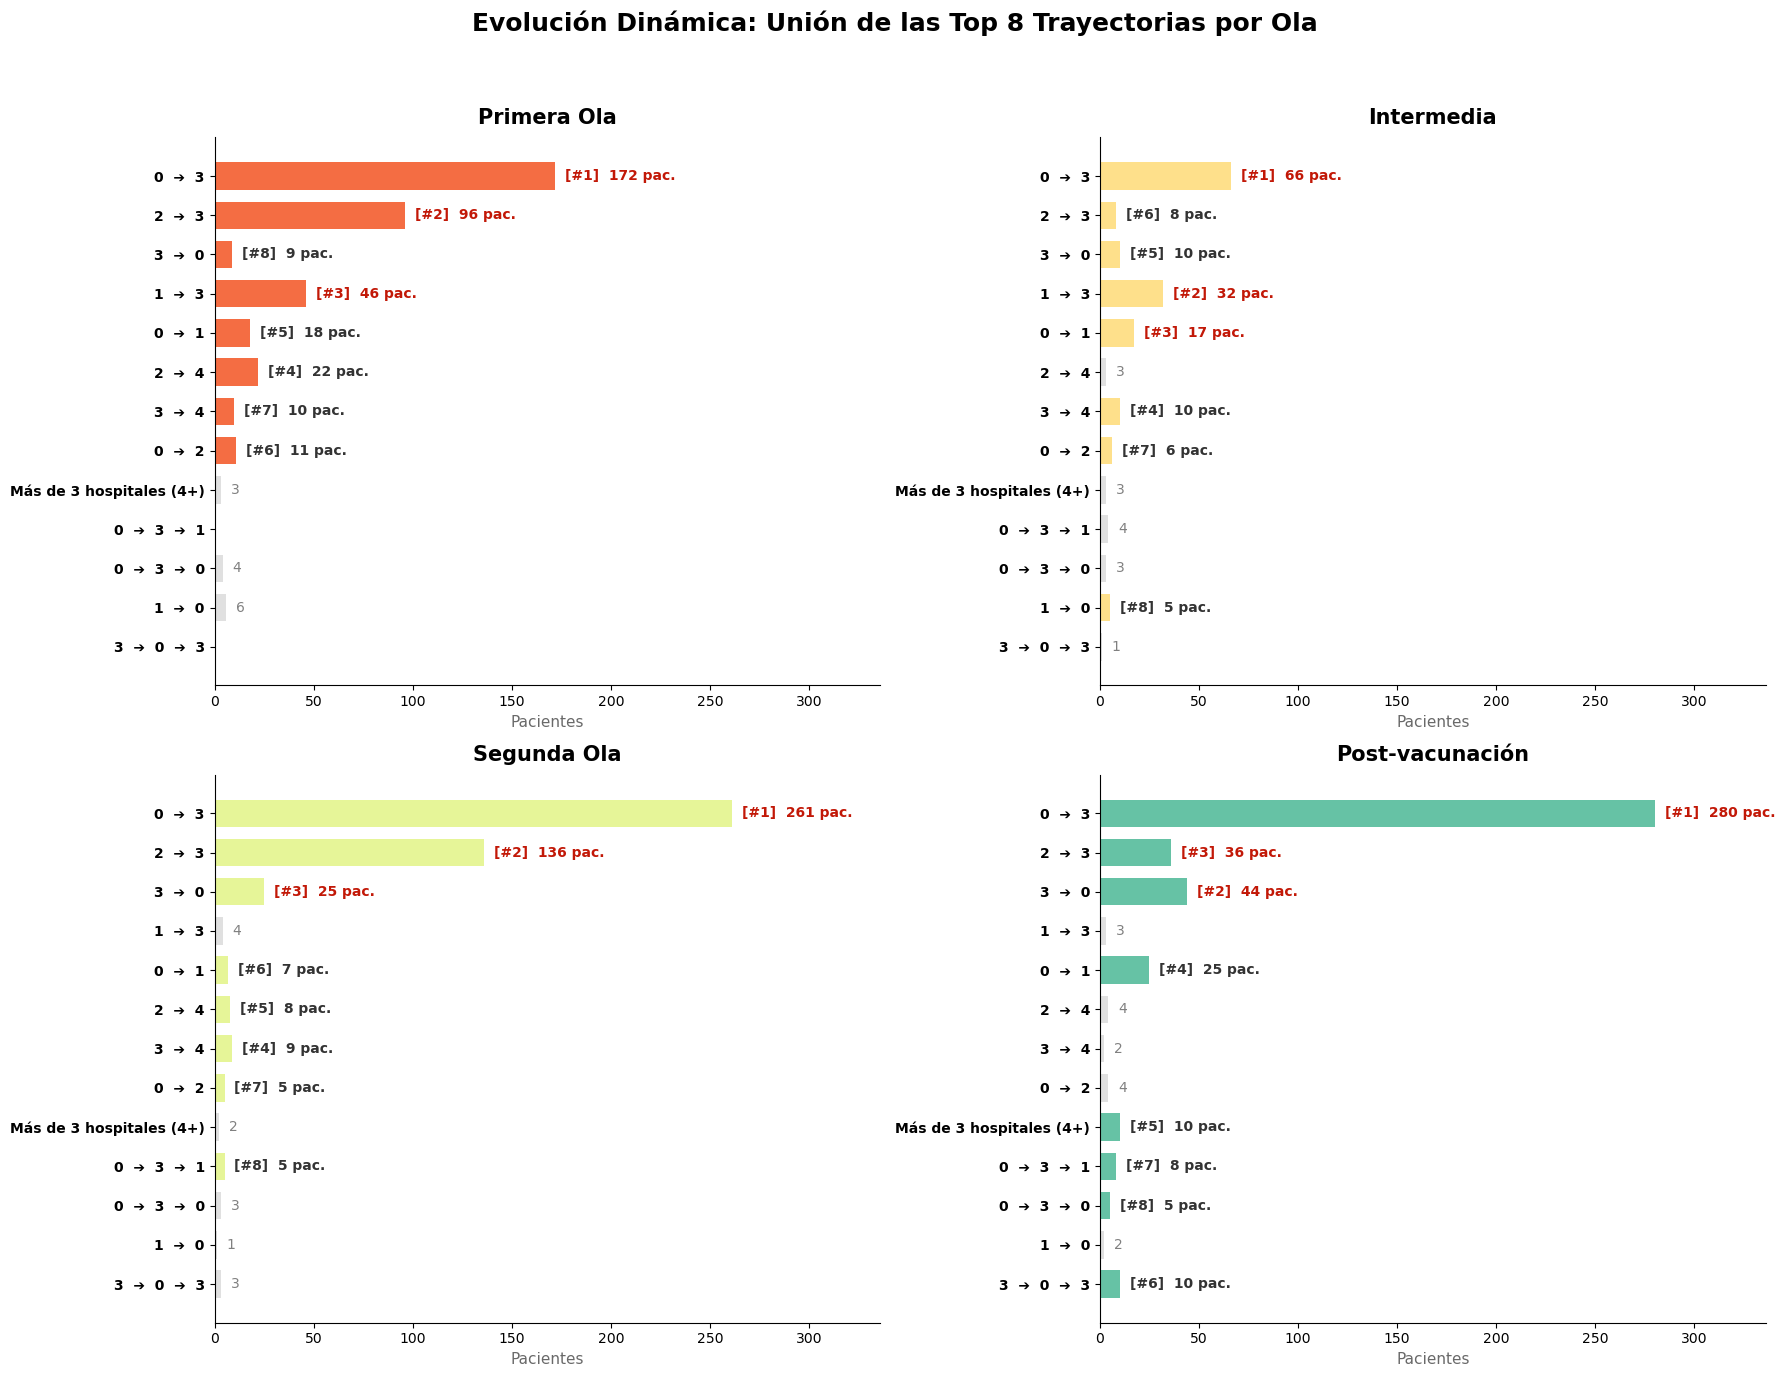

In [11]:
# GRÁFICO 6: TRAYECTORIAS COMPLETAS CON RANKING DINÁMICO (MODIFICADO)
############################################################
N_TOP = 8
nombres_periodos = [p[0] for p in PERIODOS_COVID]

# AHORA USA LA COLUMNA AGRUPADA ('ruta_para_top')
df_trayectorias_validas = trayectorias[
    (trayectorias['Periodo_Covid'].isin(nombres_periodos)) & 
    (trayectorias['ruta_para_top'].notna())
].copy()

# Reemplaza la flecha solo si no es la categoría nueva que agrupa textos
df_trayectorias_validas['ruta_formateada'] = df_trayectorias_validas['ruta_para_top'].apply(
    lambda x: str(x).replace('->', ' ➔ ') if 'hospitales' not in str(x) else str(x)
)

top_por_periodo = {}
rutas_union = set()

for periodo in nombres_periodos:
    df_periodo = df_trayectorias_validas[df_trayectorias_validas['Periodo_Covid'] == periodo]
    conteos_periodo = df_periodo['ruta_formateada'].value_counts().head(N_TOP)
    top_por_periodo[periodo] = conteos_periodo
    rutas_union.update(conteos_periodo.index)

volumen_global = df_trayectorias_validas[
    df_trayectorias_validas['ruta_formateada'].isin(rutas_union)
]['ruta_formateada'].value_counts(ascending=True)
rutas_ordenadas = volumen_global.index.tolist()

df_cantidades = pd.DataFrame(0, index=rutas_ordenadas, columns=nombres_periodos)
df_rankings = pd.DataFrame(np.nan, index=rutas_ordenadas, columns=nombres_periodos)

for periodo in nombres_periodos:
    cantidades_totales_periodo = df_trayectorias_validas[
        df_trayectorias_validas['Periodo_Covid'] == periodo
    ]['ruta_formateada'].value_counts()
    
    for ruta in rutas_ordenadas:
        df_cantidades.at[ruta, periodo] = cantidades_totales_periodo.get(ruta, 0)
    
    if periodo in top_por_periodo:
        top_rutas = top_por_periodo[periodo].index
        for rank, ruta in enumerate(top_rutas, 1): 
            df_rankings.at[ruta, periodo] = rank

graficar_grilla_trayectorias_dinamico(df_cantidades, df_rankings, nombres_periodos, n_top=N_TOP)

In [12]:
# # GRÁFICO 7: DISTRIBUCIÓN DE CANTIDAD DE TRASLADOS (CON 0 TRASLADOS) APILADO
# ############################################################
# # 1. Rescatamos TODOS los pacientes desde df_pacientes (Hoja 1)
# df_pacientes['motivo_egreso'] = df_pacientes['motivo_egreso'].fillna('otro/desconocido')

# # Sacamos el último registro de cada paciente para saber cómo terminó su caso
# ultimo_motivo = df_pacientes.groupby('paciente_id')['motivo_egreso'].last().reset_index()

# # Aplicamos las reglas de motivos para que coincidan con los colores
# condiciones_motivo = [
#     ultimo_motivo['motivo_egreso'].str.lower() == 'alta-domiciliaria',
#     ultimo_motivo['motivo_egreso'].str.lower() == 'muerte',
#     ultimo_motivo['motivo_egreso'].str.lower() == 'traslado-otro',
#     ultimo_motivo['motivo_egreso'].str.lower() == 'traslado-extra-sanitario'
# ]
# resultados_motivo = ['alta', 'muerte', 'hospital externo', 'alta hotel']
# ultimo_motivo['motivo_fin_caso'] = np.select(condiciones_motivo, resultados_motivo, default='otro/desconocido')

# # 2. Traemos la cantidad de traslados de la hoja de trayectorias
# traslados_count = trayectorias[['paciente_id', 'cantidad_traslados']].drop_duplicates()

# # Unimos. El que no cruzó (no está en trayectorias) es porque tuvo 0 traslados
# df_distribucion = ultimo_motivo.merge(traslados_count, on='paciente_id', how='left')
# df_distribucion['cantidad_traslados'] = df_distribucion['cantidad_traslados'].fillna(0)

# # 3. Agrupamos en las 5 barras que pediste: 0, 1, 2, 3, y 4 o más
# def categorizar_cantidad(cant):
#     if cant >= 4:
#         return '4 o más traslados'
#     elif cant == 1:
#         return '1 traslado'
#     else:
#         return f"{int(cant)} traslados"

# df_distribucion['grupo_traslados'] = df_distribucion['cantidad_traslados'].apply(categorizar_cantidad)

# # 4. Agrupamos y pivoteamos para el gráfico
# pivot_distribucion = df_distribucion.groupby(['grupo_traslados', 'motivo_fin_caso']).size().unstack(fill_value=0)

# # Reordenamos el índice para que en el gráfico queden ordenados de arriba hacia abajo lógicamente
# orden_grupos = ['4 o más traslados', '3 traslados', '2 traslados', '1 traslado', '0 traslados']
# # Filtramos solo los que existan por si en alguna muestra no hay de 4, etc.
# orden_grupos = [g for g in orden_grupos if g in pivot_distribucion.index] 
# pivot_distribucion = pivot_distribucion.reindex(orden_grupos)

# # 5. Graficamos usando tu misma función
# graficar_top_10_apilado(
#     df_pivot=pivot_distribucion,
#     titulo="Distribución de Pacientes según Cantidad de Traslados",
#     xlabel="Cantidad de Pacientes (Absoluta)",
#     ylabel="Niveles de Derivación",
#     total_general=len(df_distribucion),
#     sufijo="pac."
# )

In [14]:
print("\n--- COLUMNAS EN DF_SIN_TRASLADOS_MOTIVO ---")
print(df_sin_traslados_motivo.columns.tolist())
print("-" * 50)

print("\n--- COLUMNAS EN TRAYECTORIAS ---")
print(trayectorias.columns.tolist())
print("-" * 50)


--- COLUMNAS EN DF_SIN_TRASLADOS_MOTIVO ---
['hospital_id', 'hospital_origen', 'paciente_id', 'fecha_ingreso', 'estado_ingreso', 'tipo_ingreso', 'estado_ultimo', 'tipo_ultimo', 'sexo', 'edad', 'riesgo_clinico', 'riesgo_social', 'comorbilidades_covid', 'comorbilidades_pediatria', 'vacuna', 'cantidad_dosis', 'fecha_dosis_1', 'fecha_dosis_2', 'validado_ministerio', 'obra_social', 'requiere_arm', 'motivo_egreso', 'operacion', 'fecha_egreso', 'fecha_ultima_actualizacion', 'paso_criticas', 'paso_intermedias', 'paso_generales', 'fecha_ingreso_red', 'fecha_egreso_red', 'motivos_historial', 'motivo_fin_caso_x', 'hospital_destino', 'fecha_ingreso_destino', 'estado_destino', 'tipo_destino', 'dias_traslado', 'Nombre Hospital', 'complejidad', 'ruta_complejidad_str', 'motivo_fin_caso_y']
--------------------------------------------------

--- COLUMNAS EN TRAYECTORIAS ---
['paciente_id', 'ruta_hospitales_str', 'ruta_tipos_str', 'ruta_tipos_num_str', 'ruta_complejidad_str', 'ruta_hospitales_array', '

In [20]:
# ==========================================================
# TABLA RESUMEN CLÍNICA AVANZADA (ESTACIONARIOS VS TRASLADOS)
# ==========================================================
import numpy as np

# 1. Preparar un DataFrame analítico unificado
df_analisis = df_pacientes.copy()

# Parsear fechas de forma segura para calcular estadías
df_analisis['fecha_ingreso_dt'] = pd.to_datetime(df_analisis['fecha_ingreso'], errors='coerce')
df_analisis['fecha_egreso_dt'] = pd.to_datetime(df_analisis['fecha_egreso'], errors='coerce')
df_analisis['dias_estadia'] = (df_analisis['fecha_egreso_dt'] - df_analisis['fecha_ingreso_dt']).dt.days

# Asignar período COVID general a cada paciente
df_analisis['Periodo_Covid'] = df_analisis['fecha_ingreso_dt'].apply(
    lambda x: asignar_periodo(x, PERIODOS_COVID) if pd.notna(x) else 'Sin Dato'
)

# --- ESTA ES LA LÍNEA NUEVA PARA ARREGLAR EL ERROR DE LA EDAD ---
df_analisis['edad'] = pd.to_numeric(df_analisis['edad'], errors='coerce')
# ----------------------------------------------------------------

# Traer la cantidad de traslados para saber si se movió o no
traslados_info = trayectorias[['paciente_id', 'cantidad_traslados']].drop_duplicates(subset=['paciente_id'])
df_analisis = df_analisis.merge(traslados_info, on='paciente_id', how='left')

# Crear flags (Banderas booleanas)
df_analisis['es_trasladado'] = df_analisis['cantidad_traslados'].notna()
df_analisis['cantidad_traslados'] = df_analisis['cantidad_traslados'].fillna(0)

# Limpiar variables clínicas
df_analisis['requiere_arm_bool'] = df_analisis['requiere_arm'].astype(str).str.lower().isin(['si', 'sí', 'true', '1'])
df_analisis['motivo_egreso_clean'] = df_analisis['motivo_egreso'].astype(str).str.lower().str.strip()
df_analisis['fallecido'] = df_analisis['motivo_egreso_clean'] == 'muerte'
df_analisis['alta_exitosa'] = df_analisis['motivo_egreso_clean'].isin(['alta', 'alta-domiciliaria', 'alta hotel'])

# 2. Estructura de la Tabla
nombres_periodos = [p[0] for p in PERIODOS_COVID]
columnas_tabla = nombres_periodos + ['Total Global']

metricas = [
    "PERFIL CLÍNICO",
    "Edad Promedio (Años)",
    "Requirió Respirador - ARM (\\%)",
    "Estadía Promedio (Días)",
    "DINÁMICA DE RED",
    "Pacientes hiper-movilizados (≥2 traslados)",
    "DESENLACES CLÍNICOS",
    "Mortalidad (\\%)",
    "Tasa de Altas (\\%)"
]

df_avanzado = pd.DataFrame(index=metricas, columns=columnas_tabla)

# 3. Calcular las métricas "Jugosas"
for periodo in columnas_tabla:
    
    if periodo == 'Total Global':
        df_p = df_analisis[df_analisis['Periodo_Covid'].isin(nombres_periodos)]
    else:
        df_p = df_analisis[df_analisis['Periodo_Covid'] == periodo]
        
    df_est = df_p[~df_p['es_trasladado']]
    df_tra = df_p[df_p['es_trasladado']]
    
    # Función auxiliar para armar el texto "Estacionario | Trasladado"
    def comparar(metrica_est, metrica_tra, is_pct=False, is_int=False):
        if is_int:
            return f"{int(metrica_est)} | {int(metrica_tra)}"
        elif is_pct:
            return f"{metrica_est:.1f}\\% | {metrica_tra:.1f}\\%"
        else:
            return f"{metrica_est:.1f} | {metrica_tra:.1f}"

    # Separadores visuales (vacíos)
    df_avanzado.at["PERFIL CLÍNICO", periodo] = "Fijo | Movido"
    df_avanzado.at["DINÁMICA DE RED", periodo] = "Fijo | Movido"
    df_avanzado.at["DESENLACES CLÍNICOS", periodo] = "Fijo | Movido"

    # Edad Promedio
    edad_e = df_est['edad'].mean() if len(df_est) > 0 else 0
    edad_t = df_tra['edad'].mean() if len(df_tra) > 0 else 0
    df_avanzado.at["Edad Promedio (Años)", periodo] = comparar(edad_e, edad_t)

    # Requirió ARM (%)
    arm_e = (df_est['requiere_arm_bool'].mean() * 100) if len(df_est) > 0 else 0
    arm_t = (df_tra['requiere_arm_bool'].mean() * 100) if len(df_tra) > 0 else 0
    df_avanzado.at["Requirió Respirador - ARM (\\%)", periodo] = comparar(arm_e, arm_t, is_pct=True)

    # Estadía Promedio
    estadia_e = df_est['dias_estadia'].mean() if len(df_est) > 0 else 0
    estadia_t = df_tra['dias_estadia'].mean() if len(df_tra) > 0 else 0
    df_avanzado.at["Estadía Promedio (Días)", periodo] = comparar(estadia_e, estadia_t)

    # Hiper-movilizados (solo aplica a trasladados)
    hiper = len(df_tra[df_tra['cantidad_traslados'] >= 2])
    pct_hiper = (hiper / len(df_tra) * 100) if len(df_tra) > 0 else 0
    df_avanzado.at["Pacientes hiper-movilizados (≥2 traslados)", periodo] = f"- | {hiper} ({pct_hiper:.1f}\\%)"

    # Mortalidad (%)
    muertes_e = (df_est['fallecido'].mean() * 100) if len(df_est) > 0 else 0
    muertes_t = (df_tra['fallecido'].mean() * 100) if len(df_tra) > 0 else 0
    df_avanzado.at["Mortalidad (\\%)", periodo] = comparar(muertes_e, muertes_t, is_pct=True)

    # Tasa de altas exitosas (%)
    altas_e = (df_est['alta_exitosa'].mean() * 100) if len(df_est) > 0 else 0
    altas_t = (df_tra['alta_exitosa'].mean() * 100) if len(df_tra) > 0 else 0
    df_avanzado.at["Tasa de Altas (\\%)", periodo] = comparar(altas_e, altas_t, is_pct=True)


# 4. Generar el código LaTeX
df_avanzado.index.name = "Indicador (Estacionario | Trasladado)"

print("\n" + "="*80)
print("CÓDIGO LATEX GENERADO: ANÁLISIS CLÍNICO PROFUNDO (FIJOS VS MOVIDOS)")
print("="*80 + "\n")

latex_avanzado = df_avanzado.to_latex(
    caption="Análisis comparativo de gravedad y desenlaces: Pacientes estacionarios vs. Trasladados",
    label="tab:analisis_clinico_traslados",
    column_format="l" + "c" * len(df_avanzado.columns),
    escape=False
)

# Estilado extra para resaltar los títulos de sección en LaTeX
latex_avanzado = latex_avanzado.replace('PERFIL CLÍNICO', '\\midrule \\textbf{PERFIL CLÍNICO}')
latex_avanzado = latex_avanzado.replace('DINÁMICA DE RED', '\\midrule \\textbf{DINÁMICA DE RED}')
latex_avanzado = latex_avanzado.replace('DESENLACES CLÍNICOS', '\\midrule \\textbf{DESENLACES CLÍNICOS}')

print(latex_avanzado)

df_avanzado


CÓDIGO LATEX GENERADO: ANÁLISIS CLÍNICO PROFUNDO (FIJOS VS MOVIDOS)

\begin{table}
\caption{Análisis comparativo de gravedad y desenlaces: Pacientes estacionarios vs. Trasladados}
\label{tab:analisis_clinico_traslados}
\begin{tabular}{lccccc}
\toprule
 & Primera Ola & Intermedia & Segunda Ola & Post-vacunación & Total Global \\
Indicador (Estacionario | Trasladado) &  &  &  &  &  \\
\midrule
\midrule \textbf{PERFIL CLÍNICO} & Fijo | Movido & Fijo | Movido & Fijo | Movido & Fijo | Movido & Fijo | Movido \\
Edad Promedio (Años) & 47.9 | 51.9 & 47.0 | 53.1 & 50.1 | 51.6 & 45.5 | 51.5 & 47.3 | 51.8 \\
Requirió Respirador - ARM (\%) & 0.0\% | 0.0\% & 0.0\% | 0.0\% & 1.1\% | 0.9\% & 0.4\% | 1.4\% & 0.4\% | 0.7\% \\
Estadía Promedio (Días) & 9.0 | 7.1 & 10.2 | 6.7 & 11.2 | 6.8 & 10.1 | 5.0 & 10.1 | 6.3 \\
\midrule \textbf{DINÁMICA DE RED} & Fijo | Movido & Fijo | Movido & Fijo | Movido & Fijo | Movido & Fijo | Movido \\
Pacientes hiper-movilizados (≥2 traslados) & - | 94 (9.8\%) & - | 71 (17

,Primera Ola,Intermedia,Segunda Ola,Post-vacunación,Total Global
Indicador (Estacionario | Trasladado),,,,,
PERFIL CLÍNICO,Fijo | Movido,Fijo | Movido,Fijo | Movido,Fijo | Movido,Fijo | Movido
Edad Promedio (Años),47.9 | 51.9,47.0 | 53.1,50.1 | 51.6,45.5 | 51.5,47.3 | 51.8
Requirió Respirador - ARM (\%),0.0\% | 0.0\%,0.0\% | 0.0\%,1.1\% | 0.9\%,0.4\% | 1.4\%,0.4\% | 0.7\%
Estadía Promedio (Días),9.0 | 7.1,10.2 | 6.7,11.2 | 6.8,10.1 | 5.0,10.1 | 6.3
DINÁMICA DE RED,Fijo | Movido,Fijo | Movido,Fijo | Movido,Fijo | Movido,Fijo | Movido
Pacientes hiper-movilizados (≥2 traslados),- | 94 (9.8\%),- | 71 (17.2\%),- | 79 (7.5\%),- | 171 (16.5\%),- | 415 (12.0\%)
DESENLACES CLÍNICOS,Fijo | Movido,Fijo | Movido,Fijo | Movido,Fijo | Movido,Fijo | Movido
Mortalidad (\%),11.8\% | 8.3\%,9.6\% | 4.6\%,18.2\% | 9.3\%,7.1\% | 2.3\%,10.9\% | 6.4\%
Tasa de Altas (\%),55.0\% | 30.3\%,61.7\% | 32.4\%,55.2\% | 28.5\%,63.7\% | 28.1\%,59.7\% | 29.3\%
